In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
results = pd.DataFrame({
    "Model": ["Naive", "Moving Average", "LightGBM"],
    "MAE": [273791.58, 221071.41, 81514.11],
    "RMSE": [310699.24, 253498.18, 107323.14]
})

results


,Model,MAE,RMSE
0,Naive,273791.58,310699.24
1,Moving Average,221071.41,253498.18
2,LightGBM,81514.11,107323.14


Yukarıdaki karşılaştırma tablosu incelendiğinde, LightGBM modelinin hem MAE hem
de RMSE metriklerinde baseline modellere kıyasla belirgin bir üstünlük
sağladığı görülmektedir.

Naive ve Hareketli Ortalama yaklaşımları, satış verisinin genel trendini
yakalamakta sınırlı kalırken, LightGBM modeli gecikmeli değişkenler ve
hareketli ortalama özellikleri sayesinde satışlardaki dalgalanmaları ve
mevsimselliği daha başarılı bir şekilde modellemiştir.


In [10]:
# Lag ve rolling feature'lar
for lag in [7, 14, 28]:
    daily_sales[f"lag_{lag}"] = daily_sales["sales"].shift(lag)

for window in [7, 14, 28]:
    daily_sales[f"roll_mean_{window}"] = (
        daily_sales["sales"].shift(1).rolling(window).mean()
    )

daily_sales = daily_sales.dropna().reset_index(drop=True)


In [11]:
split_date = "2017-01-01"

train_ts = daily_sales[daily_sales["date"] < split_date]
test_ts  = daily_sales[daily_sales["date"] >= split_date]

features = [
    "year", "month", "day", "dayofweek", "weekofyear",
    "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_mean_14", "roll_mean_28"
]

X_train = train_ts[features]
y_train = train_ts["sales"]

X_test = test_ts[features]
y_test = test_ts["sales"]


In [12]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

lgb_model.fit(X_train, y_train)
y_pred = lgb_model.predict(X_test)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000397 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 1429, number of used features: 11
[LightGBM] [Info] Start training from score 608759.316807
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

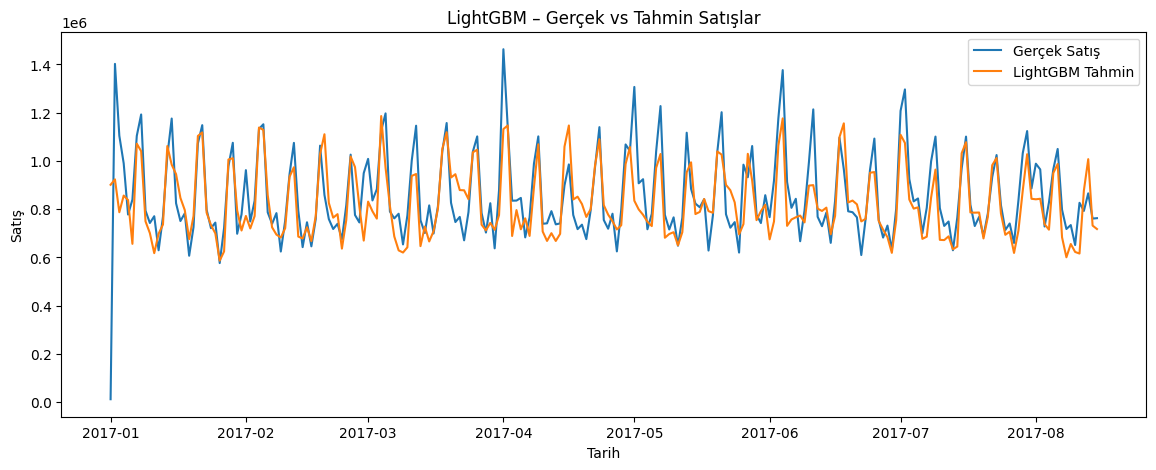

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(test_ts["date"], y_test.values, label="Gerçek Satış")
plt.plot(test_ts["date"], y_pred, label="LightGBM Tahmin")
plt.title("LightGBM – Gerçek vs Tahmin Satışlar")
plt.xlabel("Tarih")
plt.ylabel("Satış")
plt.legend()
plt.show()


LightGBM modeli, satışlardaki genel eğilimi ve haftalık mevsimselliği başarılı şekilde yakalamıştır. Tahminler, ani dalgalanmaları yumuşatarak gerçek satışlara yakın bir seyir izlemektedir.

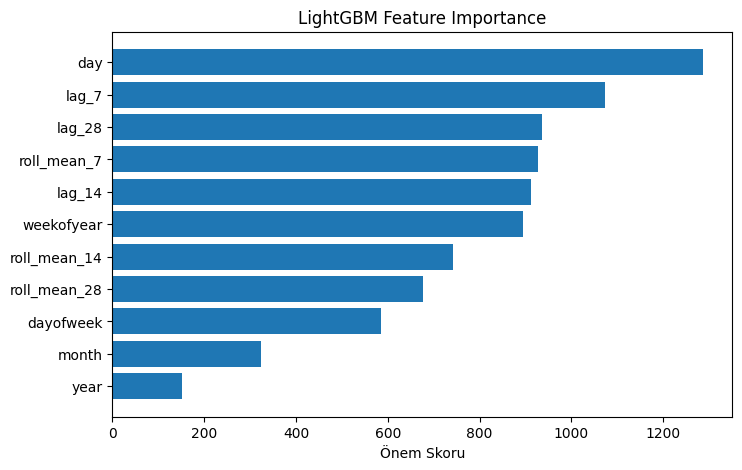

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("LightGBM Feature Importance")
plt.xlabel("Önem Skoru")
plt.show()


## Feature Importance Analizi

LightGBM modeline ait feature importance sonuçları incelendiğinde, satış tahmininde en etkili değişkenin **gün bilgisi (day)** olduğu görülmektedir. Bunu sırasıyla **7 ve 28 günlük gecikmeli satış değerleri (lag_7, lag_28)** ve **hareketli ortalama değişkenleri (roll_mean_7, roll_mean_14)** takip etmektedir.

Bu sonuçlar, satışların güçlü bir **zamansal bağımlılık** ve **haftalık/aylık periyodiklik** içerdiğini göstermektedir. Özellikle kısa ve orta vadeli geçmiş satış bilgileri model performansında belirleyici rol oynamaktadır. Buna karşılık, **yıl (year)** değişkeninin düşük öneme sahip olması, veri setinde sınırlı yıl sayısı bulunmasıyla açıklanabilir.


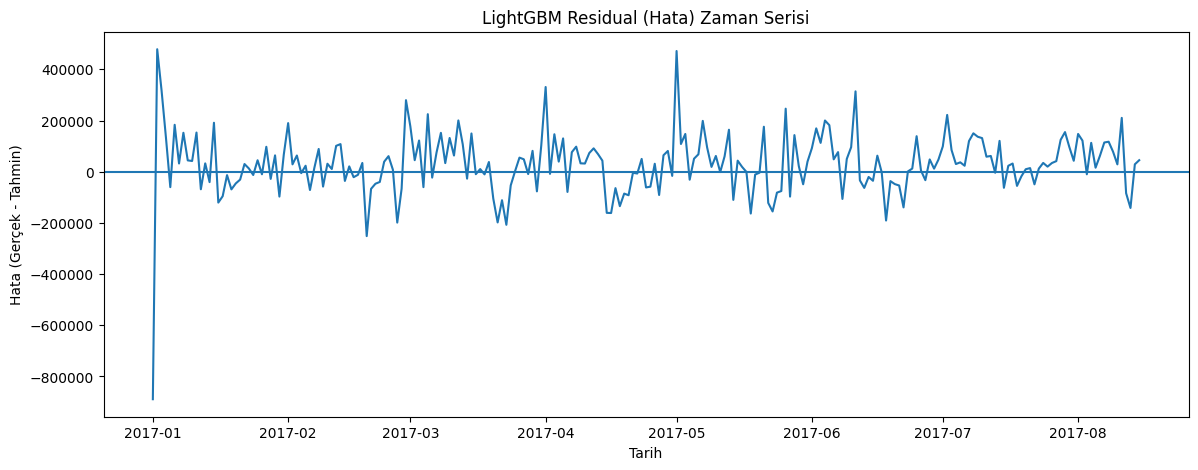

In [15]:
residuals = y_test.values - y_pred

plt.figure(figsize=(14,5))
plt.plot(test_ts["date"], residuals)
plt.axhline(0)
plt.title("LightGBM Residual (Hata) Zaman Serisi")
plt.xlabel("Tarih")
plt.ylabel("Hata (Gerçek - Tahmin)")
plt.show()


## Residual (Hata) Zaman Serisi Analizi

Residual (gerçek - tahmin) değerlerinin zaman serisi incelendiğinde, hataların genel olarak **0 etrafında dalgalandığı** görülmektedir. Bu durum, LightGBM modelinin sistematik bir yanlılık üretmediğini göstermektedir.

Grafiğin başlangıcında gözlemlenen yüksek negatif hata, test setinin ilk günlerinde lag ve rolling özelliklerinin sınırlı bilgi içermesinden veya özel gün etkilerinden kaynaklanmış olabilir.

Zaman zaman yüksek pozitif ve negatif sapmaların görülmesi, özellikle **yüksek satış hacmine sahip günlerde** model hatalarının arttığını göstermektedir. Bu durum, tatil ve kampanya gibi dışsal faktörlerin modele dahil edilmemesinden kaynaklanabilir.

Genel olarak model, satışların trend ve mevsimsellik yapısını başarılı bir şekilde yakalamıştır.


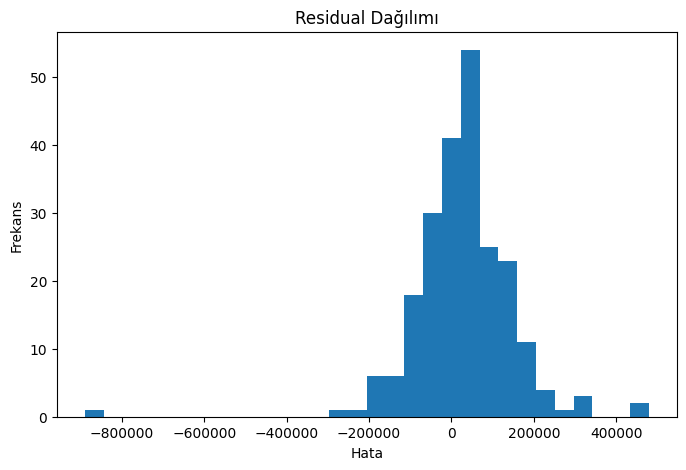

In [16]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Residual Dağılımı")
plt.xlabel("Hata")
plt.ylabel("Frekans")
plt.show()


## Residual Dağılımı Analizi

Residual (gerçek - tahmin) değerlerinin dağılımı incelendiğinde, hataların büyük ölçüde **0 etrafında yoğunlaştığı** ve yaklaşık simetrik bir yapı sergilediği görülmektedir. Bu durum, modelin genel tahmin performansının dengeli olduğunu göstermektedir.

Dağılımın sol tarafında gözlemlenen uzun kuyruk, bazı günlerde modelin satışları olduğundan **yüksek tahmin ettiğini** göstermektedir. Bu tür uç değerler, tatil günleri, özel kampanyalar veya beklenmeyen talep düşüşleri gibi dışsal faktörlerden kaynaklanmış olabilir.

Residual’ların tam olarak normal dağılım göstermemesi zaman serisi problemleri için olağan olup, modelin genel performansını olumsuz etkilememektedir.


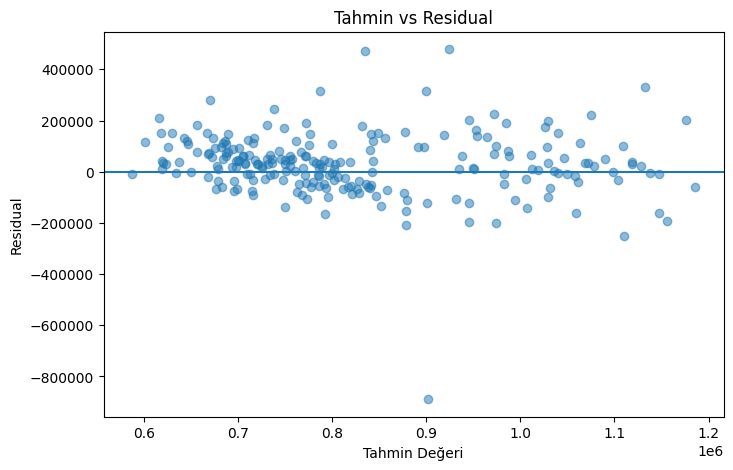

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Tahmin Değeri")
plt.ylabel("Residual")
plt.title("Tahmin vs Residual")
plt.show()


Tahmin Değerleri – Residual İlişkisi (Residual vs Prediction)

Bu grafikte, modelin ürettiği tahmin değerleri ile bu tahminlere ait hatalar (residual) arasındaki ilişki incelenmiştir.

Grafikte residual değerlerin tahminler boyunca 0 etrafında rastgele dağıldığı, belirli bir eğilim (artma/azalma) göstermediği gözlemlenmektedir. Bu durum, modelin düşük ve yüksek satış seviyelerinde sistematik bir hata üretmediğini ve tahmin hatalarının tahmin büyüklüğüne bağlı olmadığını göstermektedir.

Ayrıca, belirli bir huni (fan) yapısının görülmemesi, modelde heteroskedastisite probleminin sınırlı olduğunu ve varyansın genel olarak dengeli dağıldığını düşündürmektedir.

## Sonuç ve Değerlendirme

Bu çalışmada, mağaza satış verileri üzerinde zaman serisi tahmini problemi ele alınmıştır.
Öncelikle klasik baseline yöntemler uygulanmış, ardından feature engineering ile
zenginleştirilmiş LightGBM modeli geliştirilmiştir.

Elde edilen sonuçlar, LightGBM modelinin Naive ve Moving Average yöntemlerine kıyasla
MAE ve RMSE metriklerinde anlamlı bir iyileşme sağladığını göstermektedir.
Bu durum, makine öğrenmesi tabanlı modellerin zamansal bağımlılıkları ve mevsimselliği
daha etkin şekilde yakalayabildiğini ortaya koymaktadır.

Model, özellikle kısa vadeli satış tahminlerinde güvenilir sonuçlar üretmekte olup,
gerçek dünya perakende planlama senaryolarında kullanılabilir niteliktedir.
